In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math, os

%matplotlib inline

OUT_DIR = './saidas'
os.makedirs(OUT_DIR, exist_ok=True)

Shape: (438, 565) dtype: uint8 min/max: 28 230


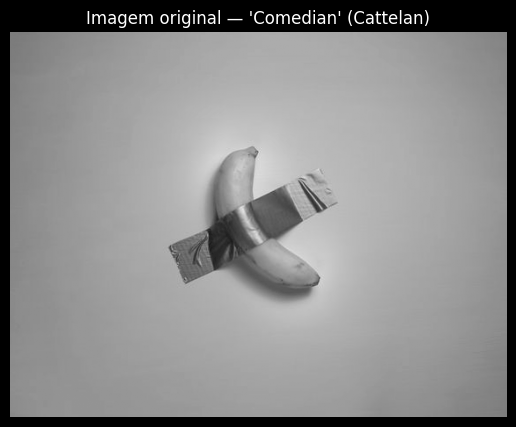

In [4]:
IMG_PATH = './arte-banana.png'
img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
assert img is not None, f'Não foi possível abrir {IMG_PATH}'

print('Shape:', img.shape, 'dtype:', img.dtype, 'min/max:', img.min(), img.max())
plt.figure(figsize=(7,5)); plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem original — 'Comedian' (Cattelan)"); plt.axis('off'); plt.show()

In [8]:
def convolucao_2d(imagem, kernel):
    imagem = imagem.astype(np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    kernel_flip = kernel[::-1, ::-1]                 # define convolução
    kh, kw = kernel_flip.shape
    ph, pw = kh // 2, kw // 2
    img_pad = np.pad(imagem, ((ph,ph),(pw,pw)), mode='edge')
    H, W = imagem.shape
    saida = np.zeros((H, W))
    for i in range(H):
        for j in range(W):
            saida[i, j] = np.sum(img_pad[i:i+kh, j:j+kw] * kernel_flip)
    return saida

def normalizar_uint8(x, modo='clip'):
    if modo == 'clip':  return np.clip(x, 0, 255).astype(np.uint8)
    if modo == 'abs':   return np.clip(np.abs(x), 0, 255).astype(np.uint8)
    if modo == 'shift':
        mn, mx = x.min(), x.max()
        if mx-mn < 1e-9: return np.zeros_like(x, dtype=np.uint8)
        return (((x-mn)/(mx-mn))*255).astype(np.uint8)

In [9]:
h1 = np.array([[ 0, 0,-1, 0, 0],
               [ 0,-1,-2,-1, 0],
               [-1,-2,16,-2,-1],
               [ 0,-1,-2,-1, 0],
               [ 0, 0,-1, 0, 0]], dtype=float)

h2 = (1/256.0)*np.array([[1, 4, 6, 4,1],
                         [4,16,24,16,4],
                         [6,24,36,24,6],
                         [4,16,24,16,4],
                         [1, 4, 6, 4,1]], dtype=float)

h3 = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)            # Sobel x
h4 = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float)            # Sobel y
h5 = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=float)       # Laplaciano
h6 = (1/9.0)*np.ones((3,3))                                          # média 3x3
h7 = np.array([[-1,-1, 2],[-1, 2,-1],[ 2,-1,-1]], dtype=float)
h8 = np.array([[ 2,-1,-1],[-1, 2,-1],[-1,-1, 2]], dtype=float)
h9 = (1/9.0)*np.eye(9)                                               # motion blur diagonal
h10 = (1/8.0)*np.array([[-1,-1,-1,-1,-1],
                        [-1, 2, 2, 2,-1],
                        [-1, 2, 8, 2,-1],
                        [-1, 2, 2, 2,-1],
                        [-1,-1,-1,-1,-1]], dtype=float)
h11 = np.array([[-1,-1,0],[-1,0,1],[0,1,1]], dtype=float)            # emboss

filtros = [('h1',h1,'abs'),('h2',h2,'clip'),('h3',h3,'abs'),('h4',h4,'abs'),
           ('h5',h5,'abs'),('h6',h6,'clip'),('h7',h7,'abs'),('h8',h8,'abs'),
           ('h9',h9,'clip'),('h10',h10,'abs'),('h11',h11,'shift')]

  aplicando h1 (5x5)...
  aplicando h2 (5x5)...
  aplicando h3 (3x3)...
  aplicando h4 (3x3)...
  aplicando h5 (3x3)...
  aplicando h6 (3x3)...
  aplicando h7 (3x3)...
  aplicando h8 (3x3)...
  aplicando h9 (9x9)...
  aplicando h10 (5x5)...
  aplicando h11 (3x3)...


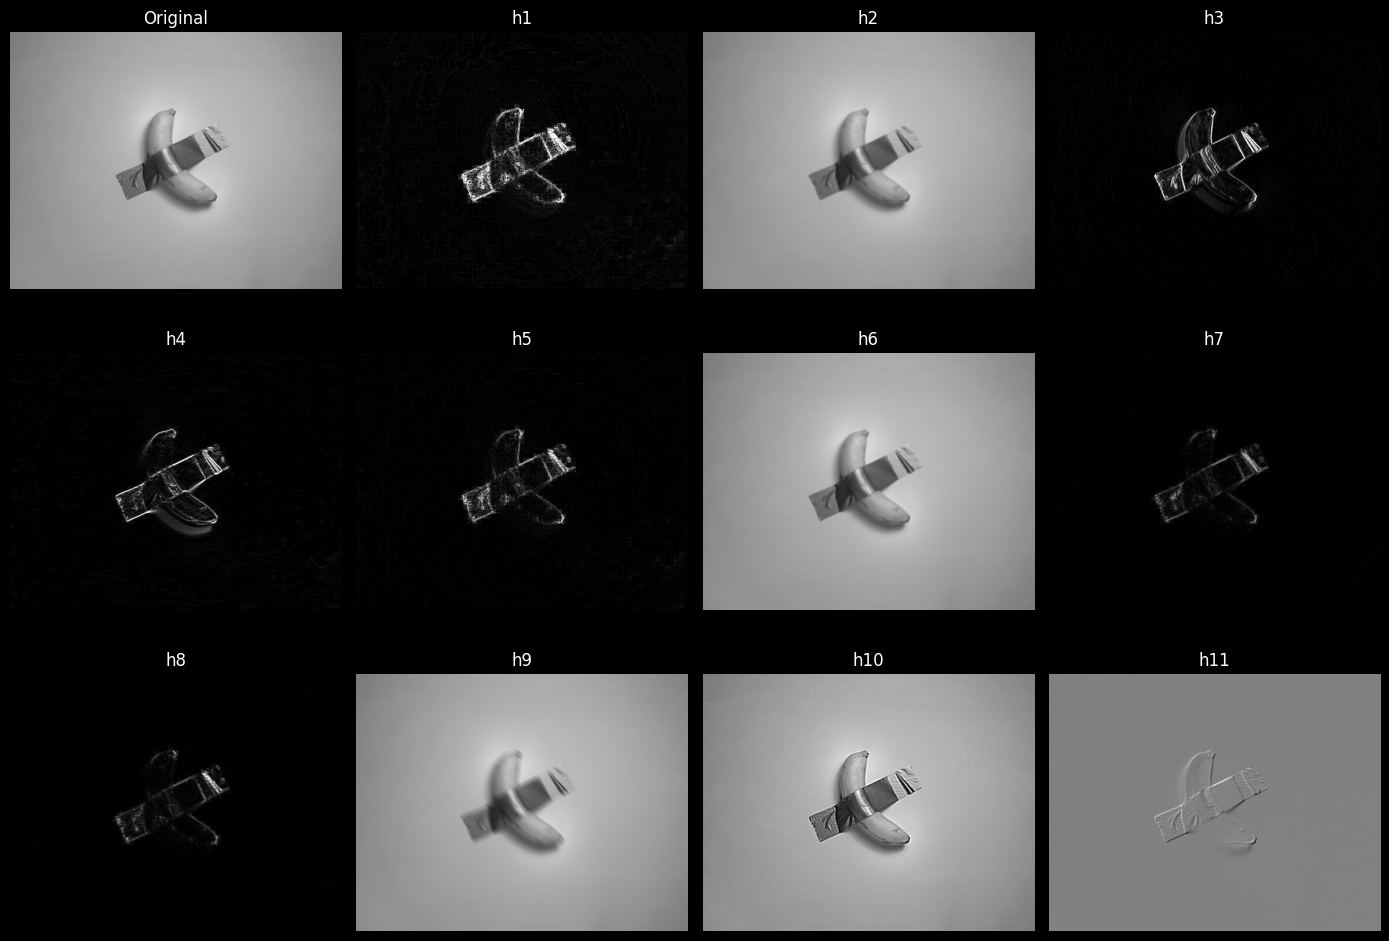

In [22]:
resultados_q1 = {}
for nome, k, modo in filtros:
    print(f'  aplicando {nome} ({k.shape[0]}x{k.shape[1]})...')
    r = convolucao_2d(img, k)
    r_u8 = normalizar_uint8(r, modo=modo)
    cv2.imwrite(f'{OUT_DIR}/q1_{nome}.png', r_u8)        # OpenCV apenas salva
    resultados_q1[nome] = r_u8

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255); axes[0].set_title('Original'); axes[0].axis('off')
for i,(nome,_,_) in enumerate(filtros, start=1):
    axes[i].imshow(resultados_q1[nome], cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(nome); axes[i].axis('off')
plt.tight_layout(); plt.show()

In [23]:
def fft2_manual(imagem):
    f = imagem.astype(np.float64)
    f = np.fft.fft(f, axis=1)
    f = np.fft.fft(f, axis=0)
    return f

def ifft2_manual(F):
    g = np.fft.ifft(F, axis=0)
    g = np.fft.ifft(g, axis=1)
    return g

def fftshift_manual(F):
    H, W = F.shape
    out = np.roll(F, shift=H//2, axis=0)
    out = np.roll(out, shift=W//2, axis=1)
    return out

def ifftshift_manual(F):
    H, W = F.shape
    out = np.roll(F, shift=-(H//2), axis=0)
    out = np.roll(out, shift=-(W//2), axis=1)
    return out

# Sanity check: reconstrução perfeita
F = fft2_manual(img); rec = np.real(ifft2_manual(F))
print(f'Erro médio absoluto FFT->IFFT: {np.mean(np.abs(rec - img)):.6f}')

Erro médio absoluto FFT->IFFT: 0.000000


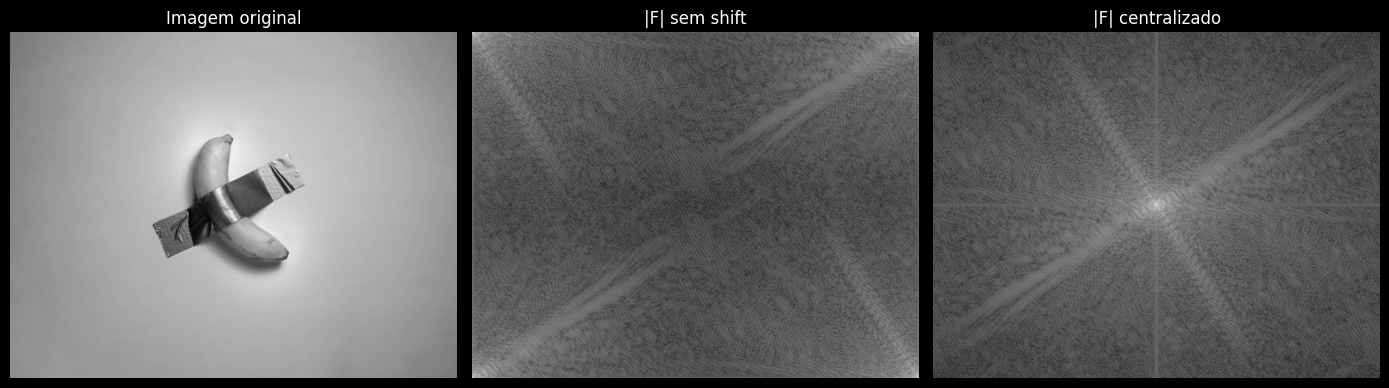

In [24]:
def espectro_vis(F):
    mag = np.log1p(np.abs(F))
    return ((mag - mag.min())/(mag.max() - mag.min() + 1e-12) * 255).astype(np.uint8)

Fc = fftshift_manual(F)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Imagem original'); axes[0].axis('off')
axes[1].imshow(espectro_vis(F), cmap='gray'); axes[1].set_title('|F| sem shift'); axes[1].axis('off')
axes[2].imshow(espectro_vis(Fc), cmap='gray'); axes[2].set_title('|F| centralizado'); axes[2].axis('off')
plt.tight_layout(); plt.show()

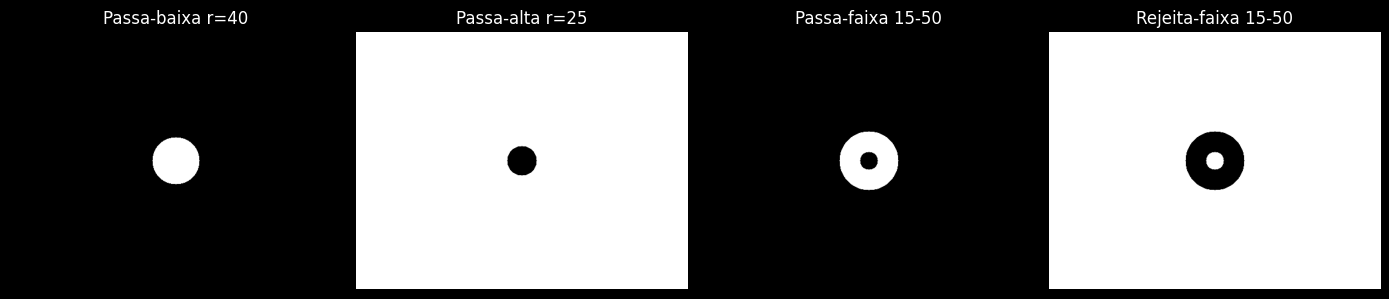

In [25]:
def mascara_circular(shape, raio):
    H, W = shape; cy, cx = H//2, W//2
    y, x = np.mgrid[0:H, 0:W]
    return (np.sqrt((y-cy)**2 + (x-cx)**2) <= raio).astype(float)

def mascara_passa_baixa(shape, r): return mascara_circular(shape, r)
def mascara_passa_alta(shape, r):  return 1.0 - mascara_circular(shape, r)
def mascara_passa_faixa(shape, ri, re):
    return mascara_circular(shape, re) - mascara_circular(shape, ri)
def mascara_rejeita_faixa(shape, ri, re):
    return 1.0 - mascara_passa_faixa(shape, ri, re)

shape = img.shape
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(mascara_passa_baixa(shape,40), cmap='gray'); axes[0].set_title('Passa-baixa r=40')
axes[1].imshow(mascara_passa_alta(shape,25),  cmap='gray'); axes[1].set_title('Passa-alta r=25')
axes[2].imshow(mascara_passa_faixa(shape,15,50), cmap='gray'); axes[2].set_title('Passa-faixa 15-50')
axes[3].imshow(mascara_rejeita_faixa(shape,15,50), cmap='gray'); axes[3].set_title('Rejeita-faixa 15-50')
for a in axes: a.axis('off')
plt.tight_layout(); plt.show()

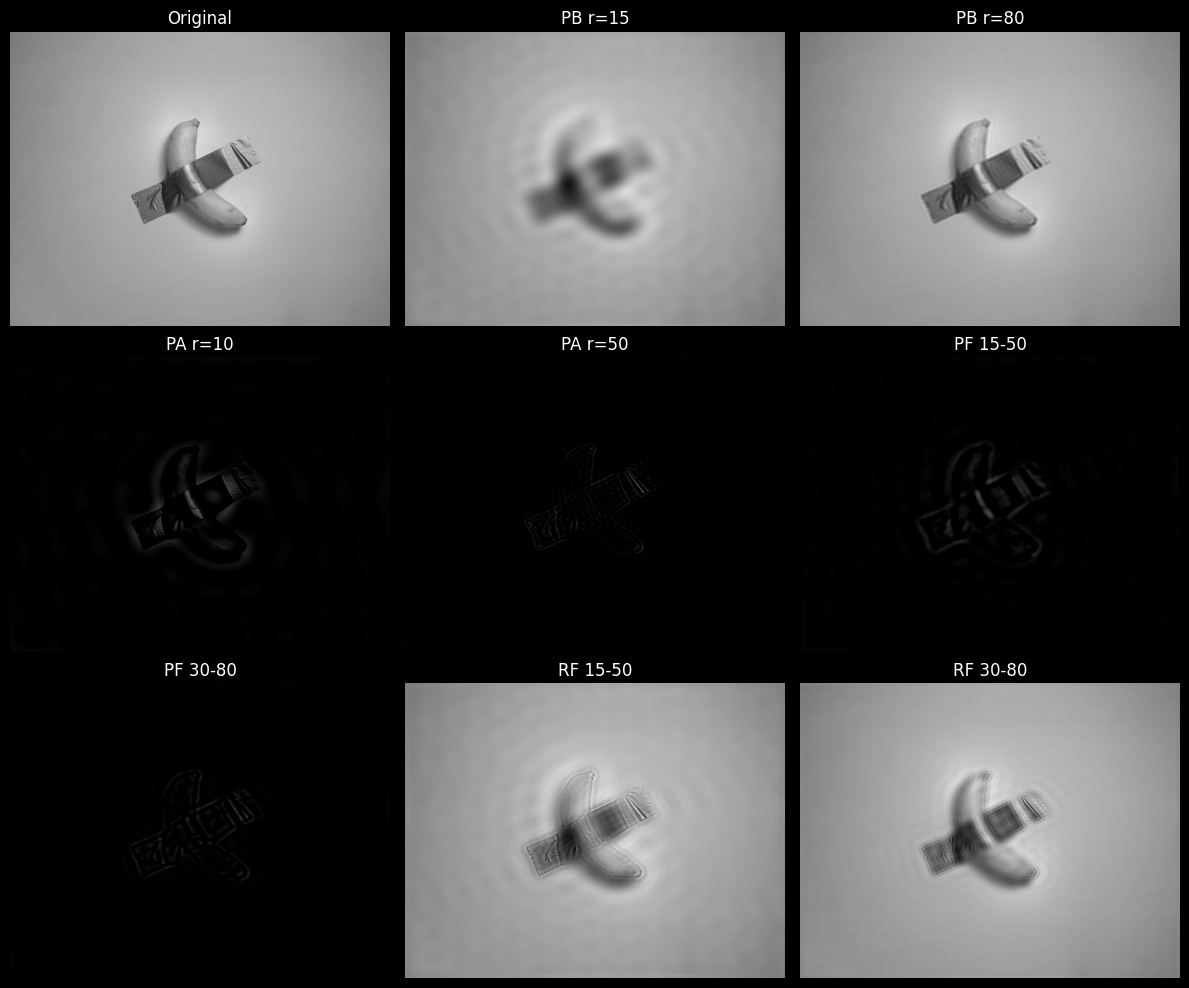

In [26]:
def aplicar_filtro_freq(imagem, mascara):
    F = fft2_manual(imagem)
    Fc = fftshift_manual(F)
    Ff = Fc * mascara
    F_back = ifftshift_manual(Ff)
    g = np.real(ifft2_manual(F_back))
    return np.clip(g, 0, 255).astype(np.uint8)

saidas = {
    'pb_15':    aplicar_filtro_freq(img, mascara_passa_baixa(shape, 15)),
    'pb_80':    aplicar_filtro_freq(img, mascara_passa_baixa(shape, 80)),
    'pa_10':    aplicar_filtro_freq(img, mascara_passa_alta(shape, 10)),
    'pa_50':    aplicar_filtro_freq(img, mascara_passa_alta(shape, 50)),
    'pf_15_50': aplicar_filtro_freq(img, mascara_passa_faixa(shape, 15, 50)),
    'pf_30_80': aplicar_filtro_freq(img, mascara_passa_faixa(shape, 30, 80)),
    'rf_15_50': aplicar_filtro_freq(img, mascara_rejeita_faixa(shape, 15, 50)),
    'rf_30_80': aplicar_filtro_freq(img, mascara_rejeita_faixa(shape, 30, 80)),
}
for nome, im in saidas.items():
    cv2.imwrite(f'{OUT_DIR}/q2_{nome}.png', im)

fig, axes = plt.subplots(3, 3, figsize=(12, 10)); axes = axes.ravel()
titulos = [('Original',img),('PB r=15',saidas['pb_15']),('PB r=80',saidas['pb_80']),
           ('PA r=10',saidas['pa_10']),('PA r=50',saidas['pa_50']),
           ('PF 15-50',saidas['pf_15_50']),('PF 30-80',saidas['pf_30_80']),
           ('RF 15-50',saidas['rf_15_50']),('RF 30-80',saidas['rf_30_80'])]
for ax,(t,im) in zip(axes, titulos):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

p=50%  MSE=   0.71  PSNR=49.62 dB
p=80%  MSE=   2.10  PSNR=44.91 dB
p=95%  MSE=   6.94  PSNR=39.72 dB
p=99%  MSE=  17.72  PSNR=35.65 dB


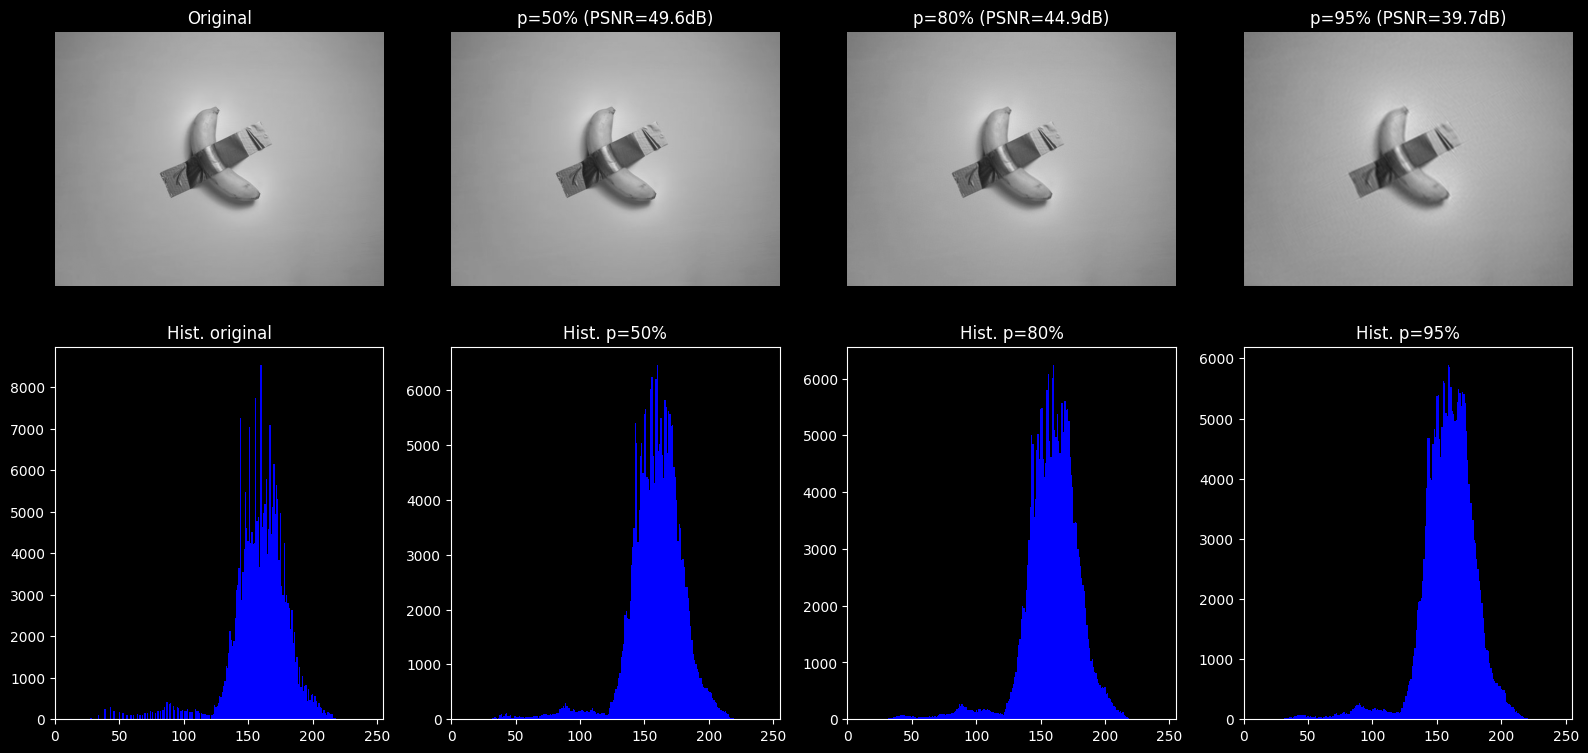

In [27]:
def comprimir(imagem, perc):
    F = fft2_manual(imagem); Fc = fftshift_manual(F)
    mag = np.abs(Fc)
    limiar = np.percentile(mag, perc)
    Ff = Fc * (mag >= limiar).astype(float)
    rec = np.real(ifft2_manual(ifftshift_manual(Ff)))
    rec = np.clip(rec, 0, 255).astype(np.uint8)
    mse  = np.mean((imagem.astype(float) - rec.astype(float))**2)
    psnr = 10*math.log10((255.0**2)/max(mse, 1e-12))
    return rec, mse, psnr

def histograma_manual(imagem):
    h = np.zeros(256, dtype=np.int64)
    for v in imagem.ravel(): h[v] += 1
    return h

percs = [50, 80, 95, 99]
comp_results = {}
for p in percs:
    rec, mse, psnr = comprimir(img, p)
    comp_results[p] = (rec, mse, psnr)
    cv2.imwrite(f'{OUT_DIR}/q2_compressao_p{p}.png', rec)
    print(f'p={p}%  MSE={mse:7.2f}  PSNR={psnr:5.2f} dB')

h_orig = histograma_manual(img)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0,0].imshow(img, cmap='gray', vmin=0, vmax=255); axes[0,0].set_title('Original'); axes[0,0].axis('off')
axes[1,0].bar(np.arange(256), h_orig, color='blue', width=1.0); axes[1,0].set_title('Hist. original'); axes[1,0].set_xlim([0,255])
for i, p in enumerate(percs[:3], start=1):
    rec, mse, psnr = comp_results[p]
    axes[0,i].imshow(rec, cmap='gray', vmin=0, vmax=255)
    axes[0,i].set_title(f'p={p}% (PSNR={psnr:.1f}dB)'); axes[0,i].axis('off')
    axes[1,i].bar(np.arange(256), histograma_manual(rec), color='blue', width=1.0)
    axes[1,i].set_title(f'Hist. p={p}%'); axes[1,i].set_xlim([0,255])
plt.tight_layout(); plt.show()